# Evidencia 1 - Fase 2 - Parte B: Implementación usando NLP

Andrea Doce Murillo - A01799931
Sandra Paulina Herrera Rebolledo - A01798452
Ian Alexei Mtz. Armendáriz - A01753288

# 1. Imports

In [32]:
#Instalación de las librerías necesarias
%pip install gensim nltk scikit-learn matplotlib pandas

#Librerias para el procesamiento de texto, modelado de Word2Vec, reducción de dimensionalidad y visualización
import re #expresiones regulares para limpieza de texto
import pandas as pd #para manejo de datos
import nltk #para procesamiento de lenguaje natural
from nltk.corpus import stopwords #para eliminar palabras vacías
from gensim.models import Word2Vec #para modelar Word2Vec
from sklearn.decomposition import PCA #para reducción de dimensionalidad
from matplotlib import pyplot as plt #para visualización

nltk.download("stopwords") #descarga de stopwords para español



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/andydoce/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 2. Convertir CSV a TXT limpio


In [33]:
# LIMPIEZA DEL CSV Y GENERACIÓN DEL TXT
from sklearn.model_selection import train_test_split #para dividir el dataset en entrenamiento y prueba

csv_path = "tweets.csv"

# Nombre del archivo TXT que se generará después de limpiar el CSV
txt_path = "tweets_limpios.txt"

# Se carga el archivo CSV.
df_csv = pd.read_csv(csv_path)


print("Valores únicos en class:", df_csv["class"].unique())

# Convertimos clase a números
df_csv["class"] = df_csv["class"].map({
    "anorexia": 1,
    "control": 0
})


# DIVISIÓN TRAIN / VALIDATION

train_df, val_df = train_test_split(
    df_csv,
    test_size=0.2,
    stratify=df_csv["class"], #esto para mantener la proporción de clases en ambos conjuntos
    random_state=42
)

# se muestra la distribución de clases en el dataset original, train y validation para verificar que se mantenga la proporción
print("\nDistribución original:")
print(df_csv["class"].value_counts(normalize=True))

print("\nTrain:")
print(train_df["class"].value_counts(normalize=True))

print("\nValidation:")
print(val_df["class"].value_counts(normalize=True))

# se guarda el dataset de validación en un nuevo CSV para usarlo posteriormente
df_csv = train_df.copy()

# Se muestran las columnas del CSV para verificar que exista tweet_text
print("Columnas encontradas en el CSV:")
print(df_csv.columns)

# Se valida que la columna tweet_text exista dentro del archivo CSV
if "tweet_text" not in df_csv.columns:
    raise ValueError("No se encontró la columna 'tweet_text' en el CSV. Revisa el nombre exacto de la columna.")

# Nos quedamos únicamente con la columna tweet_text
df_csv = df_csv[["tweet_text"]].copy()

# Eliminamos filas vacías en tweet_text
df_csv = df_csv.dropna(subset=["tweet_text"])

# Función para limpiar el texto de cada tweet
def limpiar_tweet(texto):
    texto = str(texto)                                      # asegurar que el dato sea texto
    texto = re.sub(r"http\S+|www\S+", " ", texto)         # eliminar links
    texto = re.sub(r"@\w+", " ", texto)                   # eliminar menciones
    texto = re.sub(r"#", " ", texto)                       # quitar símbolo # y conservar palabra
    texto = re.sub(r"\s+", " ", texto).strip()             # quitar espacios extra
    return texto

# Se aplica la limpieza a la columna tweet_text
df_csv["tweet_text"] = df_csv["tweet_text"].apply(limpiar_tweet)

# Se eliminan tweets que hayan quedado vacíos después de la limpieza
df_csv = df_csv[df_csv["tweet_text"] != ""]

# Se guarda solo el contenido de tweet_text en formato TXT
# Cada tweet queda en una línea diferente, sin encabezado ni índice
df_csv["tweet_text"].to_csv(txt_path, index=False, header=False)

print(f"Archivo TXT generado correctamente: {txt_path}")
print(f"Total de tweets guardados: {len(df_csv)}")

# Vista previa de los primeros tweets limpios
df_csv.head(10)


Valores únicos en class: <StringArray>
['anorexia', 'control']
Length: 2, dtype: str

Distribución original:
class
1    0.536
0    0.464
Name: proportion, dtype: float64

Train:
class
1    0.535
0    0.465
Name: proportion, dtype: float64

Validation:
class
1    0.54
0    0.46
Name: proportion, dtype: float64
Columnas encontradas en el CSV:
Index(['user_id', 'tweet_id', 'tweet_text', 'class'], dtype='str')
Archivo TXT generado correctamente: tweets_limpios.txt
Total de tweets guardados: 200


,tweet_text
211,¡Hoy me he levantado con ganas de currarme el ...
228,"El ayuno fue un fracaso, mañana intentaré una ..."
201,Cena noodles de arroz con salteado de verduras...
168,"Lo único bueno de mi dia fue comer, bañarme y ..."
124,"Buenas tardes amig , dime que tienes que hacer..."
125,5 cosas que debes saber antes de empezar a lev...
142,Some thinspo my bebs thinspo anaandmia
12,Jamas entendere a las personas que llegan a ex...
132,"Princesas, mastiquen papel. Tiene propiedades ..."
54,Y ahora me acuerdo de cuándo la báscula era mi...


# 3. Cargar el archivo TXT limpio

In [34]:
#se carga el archivo TXT generado para verificar su contenido
file_path = "tweets_limpios.txt"

# Función para corregir mojibake (caracteres extraños) en el texto
def fix_mojibake(text):
    try:
        return text.encode("cp1252", errors="ignore").decode("utf-8", errors="ignore")
    except Exception:
        return text

# al tener el archivo TXT, se lee su contenido para verificar que se haya guardado correctamente y corregir posibles mojibake
with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    raw_text = f.read()

# se corrige mojibake en el texto completo antes de procesarlo
raw_text = fix_mojibake(raw_text)
tweets = [line.strip() for line in raw_text.split("\n") if line.strip()]

# Se muestra una vista previa de los primeros tweets para verificar que se hayan guardado correctamente
df = pd.DataFrame({"tweet_original": tweets})
df.head(10)


,tweet_original
0,Hoy me he levantado con ganas de currarme el d...
1,"""El ayuno fue un fracaso, maana intentar una d..."
2,"""Cena noodles de arroz con salteado de verdura..."
3,"""Lo nico bueno de mi dia fue comer, baarme y v..."
4,"""Buenas tardes amig , dime que tienes que hace..."
5,5 cosas que debes saber antes de empezar a lev...
6,Some thinspo my bebs thinspo anaandmia
7,"""Jamas entendere a las personas que llegan a e..."
8,"""Princesas, mastiquen papel. Tiene propiedades..."
9,Y ahora me acuerdo de cundo la bscula era mi (...


# 4. Limpieza y preprocesamiento

In [35]:
# Preprocesamiento de texto: normalización, tokenización y eliminación de stopwords
stop_words = set(stopwords.words("spanish"))

# Se agregan stopwords personalizadas que son comunes en tweets
custom_stopwords = {
    "http", "https", "co", "rt", "via", "mas", "aqui", "hoy", "dia", "dias",
    "hacer", "quiero", "tener", "ser", "voy"
}
stop_words = stop_words.union(custom_stopwords)

# Función para normalizar el texto: convertir a minúsculas, eliminar links, menciones, símbolos, números y caracteres no alfabéticos
def normalizar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"http\S+|www\S+", " ", texto)          # quitar links
    texto = re.sub(r"@\w+", " ", texto)                    # quitar menciones
    texto = re.sub(r"#", " ", texto)                        # quitar símbolo #, dejar solo palabra
    texto = re.sub(r"\d+", " ", texto)                      # quitar números
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)          # conservar letras españolas
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

# Función para tokenizar el texto: dividir en palabras, eliminar stopwords y tokens muy cortos
def tokenizar(texto):
    texto = normalizar_texto(texto)
    tokens = texto.split()
    tokens = [t for t in tokens if len(t) > 2 and t not in stop_words]
    return tokens

# Se aplica la tokenización a la columna de tweets originales y se guarda en una nueva columna "tokens"
df["tokens"] = df["tweet_original"].apply(tokenizar)

# Se muestra una vista previa de los tweets originales junto con sus tokens para verificar que el preprocesamiento se haya aplicado correctamente
data = df["tokens"].tolist()
data = [tokens for tokens in data if len(tokens) > 1]

#se imprime una vista previa de los tokens generados para los primeros tweets
print(data[:5])


[['levantado', 'ganas', 'currarme', 'desayuno', 'buenosdas', 'goodmorning', 'reto', 'mesconcomidareal', 'caf', 'coffee', 'pandeespelta', 'aguacate', 'avocado'], ['ayuno', 'fracaso', 'maana', 'intentar', 'dieta', 'consiste', 'comer', 'pepino', 'forever', 'rexybill'], ['cena', 'noodles', 'arroz', 'salteado', 'verduras', 'setas', 'cebolla', 'zanahoria', 'brocoli', 'rico', 'rico', 'confundamento', 'gusta', 'simplemente'], ['nico', 'bueno', 'comer', 'baarme', 'vomitar', 'absolutamente', 'hermoso', 'volver', 'vomitar', 'siempre', 'siempre'], ['buenas', 'tardes', 'amig', 'dime', 'tarde', 'mejor', 'practicar', 'jueves', 'entrenamiento', 'sinexcusas', 'fit', 'gym', 'gimnasio', 'benidorm', 'personaltrainer']]


# 5. Filtrar tweets relacionados directamente con anorexia/TCA

In [36]:
# Se define un conjunto de palabras clave relacionadas con anorexia y trastornos alimenticios para identificar tweets que puedan estar relacionados con estos temas
keywords_tca = {
    "anorexia", "anorexica", "anorexic", "anoreccia", "bulimia", "bulymia",
    "tca", "trastornosalimenticios", "ana", "mia", "proana", "promia",
    "thinspo", "thinspiration", "ayunar", "vomitar", "vomito", "delgada",
    "gorda", "peso", "calorias", "hambre", "laxantes", "noteat"
}

# Se verifica si cada tweet contiene alguna de las palabras clave relacionadas con anorexia/TCA y se crea una nueva columna "es_tca" con el resultado booleano
def contiene_keyword(tokens):
    return any(token in keywords_tca for token in tokens)

# con ello se filtran los tweets que contienen alguna de las palabras clave relacionadas con anorexia/TCA y se crea un nuevo DataFrame df_tca con solo esos tweets
df["es_tca"] = df["tokens"].apply(contiene_keyword)
df_tca = df[df["es_tca"]].copy()

# Se muestra la cantidad de tweets relacionados con anorexia/TCA y una vista previa de los primeros tweets originales junto con sus tokens para verificar que se hayan identificado correctamente
data_tca = df_tca["tokens"].tolist()
data_tca = [tokens for tokens in data_tca if len(tokens) > 1]

#se imprime la cantidad de tweets relacionados con anorexia/TCA y una vista previa de los primeros tweets originales junto con sus tokens para verificar que se hayan identificado correctamente
print("Tweets relacionados con anorexia/TCA:", len(data_tca))
df_tca[["tweet_original", "tokens"]].head(10) #se muestra una vista previa de los tweets relacionados con anorexia/TCA para verificar que se hayan identificado correctamente


Tweets relacionados con anorexia/TCA: 60


,tweet_original,tokens
3,"""Lo nico bueno de mi dia fue comer, baarme y v...","[nico, bueno, comer, baarme, vomitar, absoluta..."
6,Some thinspo my bebs thinspo anaandmia,"[some, thinspo, bebs, thinspo, anaandmia]"
9,Y ahora me acuerdo de cundo la bscula era mi (...,"[ahora, acuerdo, cundo, bscula, ene, amiga, fi..."
16,vivir con tus padres y que te obliguen a comer...,"[vivir, padres, obliguen, comer, proana, promi..."
19,"""Si ana me va a llevar a ser una princesa , no...","[ana, llevar, princesa, importa, dejar, ello, ..."
21,Todo sera mas fcil si no fuera gorda,"[sera, fcil, gorda]"
37,Nos que me puede ms las ganas de morir o de ba...,"[puede, ganas, morir, bajar, peso, ana, mia, a..."
38,Como bajar peso comiendo sin parar. Tips,"[bajar, peso, comiendo, parar, tips]"
39,No sal a comer porque todos sabemos que el rui...,"[sal, comer, sabemos, ruido, estmago, aplausos..."
40,Un ao que cerramos cargado de buenos deseos y ...,"[cerramos, cargado, buenos, deseos, grandes, r..."


# 6. Entrenar modelo Word2Vec

In [37]:
# Para el modelado de Word2Vec, se utiliza el corpus de tweets relacionados con anorexia/TCA si hay suficientes datos (al menos 10 tweets), de lo contrario se utiliza el corpus completo de tweets para entrenar el modelo
corpus = data_tca if len(data_tca) >= 10 else data

# Este modelo ayuda a aprender representaciones vectoriales de palabras basadas en su contexto dentro de los tweets, esto sirve para el análisis de sentimientos, clasificación o detección de temas relacionados con anorexia y trastornos alimenticios
model = Word2Vec(
    sentences=corpus,
    vector_size=50,   # tamaño del vector de cada palabra
    sg=1,             # 1 = Skip-gram; 0 = CBOW
    window=5,         # tamaño de la ventana de contexto
    min_count=1,      # frecuencia mínima de palabras
    workers=4,        # número de trabajadores para el entrenamiento
    epochs=200,       # número de épocas de entrenamiento
    seed=42           # para reproducibilidad 
)

# se imprime una vista previa de las primeras palabras del vocabulario aprendido por el modelo Word2Vec para verificar que se hayan entrenado correctamente
print(model.wv.index_to_key[:30])


['anorexia', 'bulimia', 'proana', 'promia', 'hambre', 'ana', 'mia', 'peso', 'thinspo', 'comer', 'gorda', 'vida', 'morir', 'vez', 'bajar', 'tca', 'bulimicgirl', 'ahora', 'meta', 'llegar', 'puede', 'bulimic', 'anorexiaeetclub', 'siempre', 'volver', 'vomitar', 'nico', 'princesas', 'pesar', 'ayuno']


# 7. Vector de una palabra

In [38]:
palabra = "anorexia" # se verifica si la palabra "anorexia" está en el vocabulario del modelo y se imprime su vector de embedding y su tamaño, esto para verificar que el modelo haya aprendido una representación para esta palabra clave relacionada con el tema de anorexia/TCA

# se verifica si la palabra "anorexia" está en el vocabulario del modelo y se imprime su vector de embedding y su tamaño, esto para verificar que el modelo haya aprendido una representación para esta palabra clave relacionada con el tema de anorexia/TCA
if palabra in model.wv:
    embedding = model.wv[palabra]
    print(f"Vector para '{palabra}':")
    print(embedding)
    print("Tamaño del vector:", len(embedding))
else:
    print(f"La palabra '{palabra}' no aparece en el vocabulario.")


Vector para 'anorexia':
[-0.02311721 -0.12930295 -0.02523279  0.10008431  0.3073012   0.53040695
 -0.23753098  0.27271956 -0.08241589  0.02220565  0.38094878  0.49157676
 -0.18640597  0.47611845 -0.35927585 -0.02842553  0.38361079 -0.7118187
 -0.2852962  -0.01618203 -0.17621174  0.07922658 -0.15635505  0.0390248
  0.5817333  -0.1745594   0.07472346 -0.02655135  0.0855388   0.02516551
  0.15763777 -0.10038729 -0.00511043  0.23391372 -0.01423018 -0.11762649
  0.0567972  -0.25482193  0.03028397  0.39371386 -0.22043253  0.1086028
  0.28809115 -0.34717125 -0.3427841  -0.2743206  -0.03642758  0.5575402
  0.22932623 -0.29317525]
Tamaño del vector: 50


# 8. Palabras similares

In [39]:
# se define una lista de palabras para consultar sus palabras similares en el espacio de embedding aprendido por el modelo Word2Vec, esto para verificar que el modelo haya aprendido relaciones semánticas entre estas palabras clave 
palabras_consulta = ["anorexia", "bulimia", "tca", "delgada", "peso", "comer", "vomitar", "hambre"]

# se consulta el modelo Word2Vec para cada palabra en la lista de palabras_consulta y se imprimen las palabras más similares junto con sus puntuaciones de similitud
for palabra in palabras_consulta:
    if palabra in model.wv:
        print(f"\nPalabras similares a '{palabra}':")
        similares = model.wv.most_similar(palabra, topn=5)
        for similar, score in similares:
            print(f"{similar:15s} -> {score:.4f}")
    else:
        print(f"\n'{palabra}' no está en el vocabulario.")



Palabras similares a 'anorexia':
alimenta        -> 0.8704
bulimia         -> 0.8590
destruye        -> 0.8570
anorexiaeetclub -> 0.7436
bulimic         -> 0.7426

Palabras similares a 'bulimia':
alimenta        -> 0.8654
anorexia        -> 0.8590
destruye        -> 0.8570
bulimic         -> 0.7262
gimnasios       -> 0.7211

Palabras similares a 'tca':
bulimicgirl     -> 0.9948
anorexiaeetclub -> 0.9847
bulimic         -> 0.9817
bulimianervosa  -> 0.9731
necesito        -> 0.9687

Palabras similares a 'delgada':
espero          -> 0.9964
tengoundeseoyes -> 0.9958
perfeccion      -> 0.9927
morir           -> 0.9672
calorias        -> 0.5759

Palabras similares a 'peso':
comiendo        -> 0.9310
tips            -> 0.9278
parar           -> 0.9264
bajar           -> 0.9189
deberia         -> 0.8822

Palabras similares a 'comer':
dormir          -> 0.9380
nites           -> 0.9191
acostumbro      -> 0.8049
sal             -> 0.7651
sino            -> 0.7509

Palabras similares a 'vomitar

# 9. Visualización con PCA

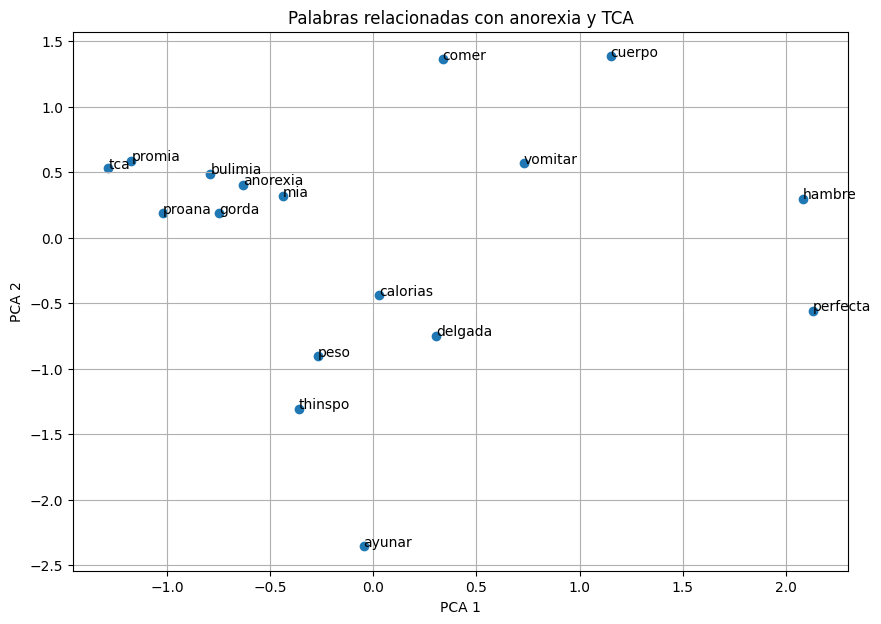

In [40]:
#en esta sección se define una función para visualizar las palabras en el espacio de embedding utilizando PCA para reducir la dimensionalidad a 2D
def visualizar_palabras(palabras, titulo="Visualización Word2Vec"):
    palabras_presentes = [p for p in palabras if p in model.wv]
    
    if len(palabras_presentes) < 2: # se verifica que haya al menos 2 palabras presentes en el vocabulario para poder graficar
        print("No hay suficientes palabras presentes en el vocabulario para graficar.")
        return
    
    X = model.wv[palabras_presentes] # se obtiene el vector de embedding para cada palabra presente en la lista de palabras
    pca = PCA(n_components=2) # se inicializa PCA para reducir a 2 dimensiones
    result = pca.fit_transform(X) # se aplica PCA para reducir la dimensionalidad de los vectores de embedding a 2D para visualización
    
    plt.figure(figsize=(10, 7)) # se crea una figura para la visualización
    plt.scatter(result[:, 0], result[:, 1])
    
    for i, word in enumerate(palabras_presentes):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]))
    
    plt.title(titulo)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.grid(True)
    plt.show()

palabras_tca = [
    "anorexia", "bulimia", "tca", "mia", "proana", "promia",
    "thinspo", "delgada", "gorda", "peso", "calorias", "hambre",
    "comer", "vomitar", "ayunar", "cuerpo", "perfecta", "saludable"
]

visualizar_palabras(palabras_tca, "Palabras relacionadas con anorexia y TCA")


# 10. Visualización de las palabras más frecuentes del vocabulario

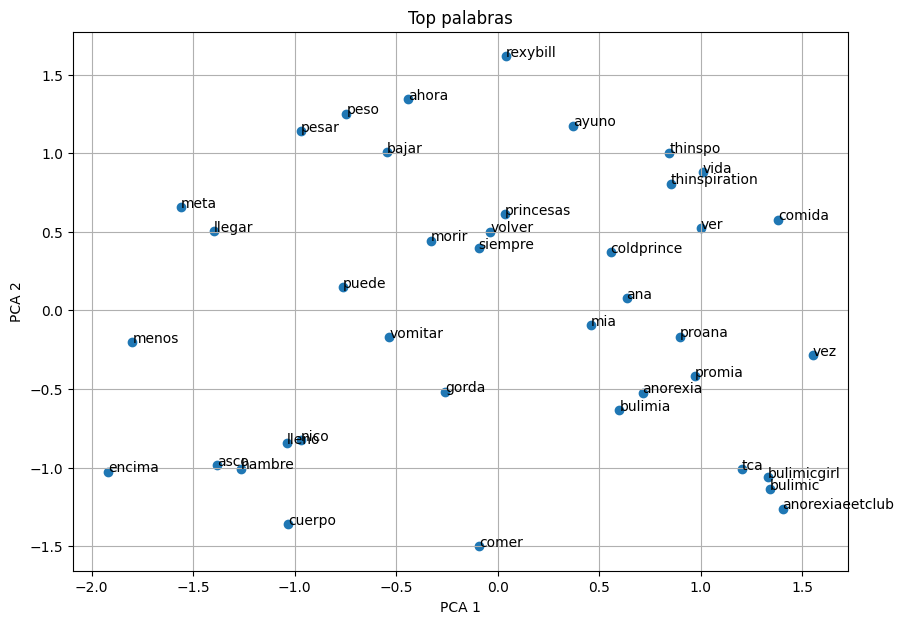

In [41]:
# se obtiene la lista de las 40 palabras más frecuentes en el vocabulario del modelo Word2Vec y se visualizan
top_words = model.wv.index_to_key[:40]
visualizar_palabras(top_words, "Top palabras")


# 11. Predicción de palabra 

In [42]:
# se define una lista de contextos para poder consultar qué palabras el modelo Word2Vec predice como más probables en esos contextos
contextos = [
    ["bajar", "peso"],
    ["comer", "culpa"],
    ["anorexia", "bulimia"],
    ["hambre", "agua"],
]

# se consulta el modelo Word2Vec para cada contexto en la lista de contextos y se imprimen las palabras más probables que el modelo predice para esos contextos
for contexto in contextos:
    contexto_presente = [p for p in contexto if p in model.wv] # se filtran las palabras del contexto para incluir solo aquellas que están presentes en el vocabulario del modelo
    print("\nContexto:", contexto_presente)
    
    #si ninguna palabra del contexto está presente en el vocabulario, se imprime un mensaje indicando que no se pueden hacer predicciones para ese contexto y se continúa con el siguiente contexto
    if len(contexto_presente) == 0:
        print("Ninguna palabra del contexto está en el vocabulario.")
        continue
    # se intenta predecir las palabras más probables para el contexto presente utilizando el modelo Word2Vec y se imprimen los resultados
    # si ocurre un error durante la predicción (por ejemplo, si el contexto no es válido para el modelo), se captura la excepción y se imprime un mensaje indicando que no se pudo predecir con ese modelo
    try:
        pred = model.predict_output_word(contexto_presente, topn=5) # se predicen las palabras más probables para el contexto presente utilizando el modelo Word2Vec
        print(pred)
    except Exception as e:
        print("No se pudo predecir con este modelo:", e)



Contexto: ['bajar', 'peso']
[('bajar', np.float32(0.10561732)), ('peso', np.float32(0.053797707)), ('amor', np.float32(0.046971735)), ('logre', np.float32(0.046595536)), ('semanas', np.float32(0.04522118))]

Contexto: ['comer']
[('comer', np.float32(0.28386757)), ('acostumbro', np.float32(0.036103796)), ('sino', np.float32(0.03025838)), ('paff', np.float32(0.022718793)), ('ruido', np.float32(0.02132719))]

Contexto: ['anorexia', 'bulimia']
[('bulimia', np.float32(0.03328139)), ('anorexia', np.float32(0.020275624)), ('obliguen', np.float32(0.016781043)), ('cada', np.float32(0.016659364)), ('anorexic', np.float32(0.016314493))]

Contexto: ['hambre']
[('hambre', np.float32(0.2405254)), ('perfecta', np.float32(0.034378294)), ('cortarte', np.float32(0.031783737)), ('huelga', np.float32(0.031358976)), ('triste', np.float32(0.029325405))]


# 12. Detección simple de posibles señales de anorexia

En esta sección se implementa una detección binaria sencilla para identificar si un tweet contiene posibles señales relacionadas con anorexia o trastornos de la conducta alimentaria.

In [43]:
# Dettección automática de posibles señales de anorexia/TCA en los tweets 
# de anorexia/TCA en los tweets

import re

# Lista de palabras relacionadas con anorexia/TCA
palabras_riesgo = [
    "anorexia", "anorexica", "proana",
    "no comer", "sin comer", "ayunar",
    "calorias", "bajar de peso", "perder peso",
    "thinspo", "odio mi cuerpo",
    "me siento gorda", "miedo a engordar",
    "vomitar", "atracon", "laxantes"
]

# Función para limpiar texto
def normalizar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+", "", texto)
    texto = re.sub(r"@\w+", "", texto)
    texto = re.sub(r"#", "", texto)
    texto = re.sub(r"[^a-záéíóúñ\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

# Función de detección
def detectar_anorexia_tweet(tweet):

    texto = normalizar_texto(tweet)

    coincidencias = []

    for palabra in palabras_riesgo:
        if normalizar_texto(palabra) in texto:
            coincidencias.append(palabra)

    puntaje = len(coincidencias)

    if puntaje >= 2 or "anorexia" in texto or "proana" in texto:
        resultado = "Posible señal de anorexia/TCA"
    else:
        resultado = "No se detectan señales claras"

    return resultado, puntaje, coincidencias

# Analizar los tweets y mostrar resultados en una tabla

resultados = []

tweets_prueba = tweets[:10]

for tweet in tweets_prueba:

    resultado, puntaje, coincidencias = detectar_anorexia_tweet(tweet)

    resultados.append({
        "Tweet": tweet.strip(),
        "Clasificación": resultado,
        "Puntaje": puntaje,
        "Coincidencias": ", ".join(coincidencias)
    })

# Convertimos a DataFrame
df_resultados = pd.DataFrame(resultados)

# Mostrar tabla
df_resultados


,Tweet,Clasificación,Puntaje,Coincidencias
0,Hoy me he levantado con ganas de currarme el d...,No se detectan señales claras,0,
1,"""El ayuno fue un fracaso, maana intentar una d...",No se detectan señales claras,0,
2,"""Cena noodles de arroz con salteado de verdura...",No se detectan señales claras,0,
3,"""Lo nico bueno de mi dia fue comer, baarme y v...",No se detectan señales claras,1,vomitar
4,"""Buenas tardes amig , dime que tienes que hace...",No se detectan señales claras,0,
5,5 cosas que debes saber antes de empezar a lev...,No se detectan señales claras,0,
6,Some thinspo my bebs thinspo anaandmia,No se detectan señales claras,1,thinspo
7,"""Jamas entendere a las personas que llegan a e...",No se detectan señales claras,0,
8,"""Princesas, mastiquen papel. Tiene propiedades...",No se detectan señales claras,0,
9,Y ahora me acuerdo de cundo la bscula era mi (...,Posible señal de anorexia/TCA,2,"anorexia, thinspo"


# 13. Comparación final de metodologías para detección de señales de anorexia/TCA



In [ ]:
# 1. IMPORTACIÓN DE LIBRERÍAS

import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score


# Librerías necesarias para procesamiento de texto, entrenamiento y evaluación de modelos


## 14. Funciones auxiliares

Estas funciones permiten normalizar tweets, detectar señales por palabras clave y crear etiquetas binarias para entrenar los modelos.

In [45]:
# Lista de palabras relacionadas con anorexia/TCA para detección de señales en los tweets
palabras_riesgo = [
    "anorexia", "anorexica", "anoréxica", "ana", "proana", "pro ana",
    "bulimia", "bulimica", "bulímica", "mia", "promia", "pro mia",
    "no comer", "dejar de comer", "sin comer", "ayunar", "ayuno",
    "calorias", "calorías", "contar calorias", "contar calorías",
    "bajar de peso", "perder peso", "peso ideal", "estar flaca", "estar flaco",
    "quiero ser flaca", "quiero ser flaco", "thinspo", "thinspiration",
    "odio mi cuerpo", "me siento gorda", "me siento gordo",
    "miedo a engordar", "restriccion", "restricción",
    "atracon", "atracón", "vomitar", "vomito", "vómito", "purgar",
    "laxantes", "culpa por comer", "comi demasiado", "comí demasiado"
]

# Funciones auxiliares para limpieza y clasificación de texto
def normalizar_texto(texto):
    """Limpia y normaliza un texto para facilitar su análisis."""
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = re.sub(r"#", " ", texto)
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

#función para detectar señales de anorexia/TCA en un tweet utilizando palabras clave, regresa una clasificación textual, un puntaje basado en la cantidad de coincidencias encontradas y una lista de las coincidencias específicas
def detectar_anorexia_tweet(tweet):
    texto = normalizar_texto(tweet)
    coincidencias = []

    for palabra in palabras_riesgo:
        palabra_normalizada = normalizar_texto(palabra)
        if palabra_normalizada in texto:
            coincidencias.append(palabra)

    puntaje = len(coincidencias)
    palabras_directas = ["anorexia", "anorexica", "anoréxica", "proana", "pro ana", "bulimia", "bulimica", "bulímica"]
    contiene_directa = any(normalizar_texto(p) in texto for p in palabras_directas)

    if puntaje >= 2 or contiene_directa:
        resultado = "Posible señal de anorexia/TCA"
    else:
        resultado = "No se detectan señales claras"

    return resultado, puntaje, coincidencias

# Función para tokenizar el texto: dividir en palabras, eliminar stopwords y tokens muy cortos
def tokenizar_texto(texto):
    """Tokeniza un tweet después de normalizarlo."""
    return normalizar_texto(texto).split()

# Funciones auxiliares para limpieza y clasificación de texto


## 15. Preparación automática del dataset

Esta celda es robusta: intenta usar las variables creadas anteriormente en el notebook (`df_resultados`, `df_csv`, `tweets`) o, si no existen, carga los datos desde `tweets.csv` o `tweets_limpios.txt`.

In [46]:
#Se prepara el dataset para entrenamiento de modelos, se generan etiquetas binarias basadas en la detección de señales de anorexia/TCA utilizando la función detectar_anorexia_tweet, se verifica que existan ambas clases (0 y 1) para poder entrenar modelos de clasificación posteriormente
df_modelos = None

# Reutilizar resultados generados previamente
if "df_resultados" in globals():
    df_modelos = df_resultados.copy()
    print("Se usó df_resultados existente.")

# Reutilizar dataset previamente cargado
elif "df_csv" in globals() and isinstance(df_csv, pd.DataFrame) and "tweet_text" in df_csv.columns:
    df_modelos = df_csv[["tweet_text"]].copy()
    print("Se usó df_csv existente.")

# Crear DataFrame a partir de la lista de tweets
elif "tweets" in globals():
    df_modelos = pd.DataFrame({"tweet_text": [str(t).strip() for t in tweets]})
    print("Se usó la lista tweets existente.")

# Cargar dataset desde archivo CSV
else:
    try:
        temp = pd.read_csv("tweets.csv")
        if "tweet_text" not in temp.columns:
            raise ValueError("El archivo tweets.csv no contiene la columna tweet_text.")
        df_modelos = temp[["tweet_text"]].copy()
        print("Se cargó tweets.csv.")
    except Exception as e_csv:
        try:
            with open("tweets_limpios.txt", "r", encoding="utf-8") as archivo:
                tweets_temp = archivo.readlines()
            df_modelos = pd.DataFrame({"tweet_text": [str(t).strip() for t in tweets_temp]})
            print("Se cargó tweets_limpios.txt.")
        except Exception as e_txt:
            raise FileNotFoundError("No se encontró una fuente válida de tweets. Revisa que exista tweets.csv con columna tweet_text o tweets_limpios.txt.")

# Verificar la existencia de la columna principal
if "tweet_text" not in df_modelos.columns:
    # Si por alguna razón la columna tiene otro nombre, usamos la primera columna como texto
    primera_columna = df_modelos.columns[0]
    df_modelos = df_modelos.rename(columns={primera_columna: "tweet_text"})
    print(f"Se renombró la columna {primera_columna} a tweet_text.")

# Eliminación de registros vacíos
df_modelos = df_modelos.dropna(subset=["tweet_text"])
df_modelos["tweet_text"] = df_modelos["tweet_text"].astype(str).str.strip()
df_modelos = df_modelos[df_modelos["tweet_text"] != ""]

# Generación automática de etiquetas binarias
if "clasificacion" not in df_modelos.columns or "puntaje_riesgo" not in df_modelos.columns:
    clasificaciones = []
    puntajes = []
    coincidencias_lista = []

    for tweet in df_modelos["tweet_text"]:
        resultado, puntaje, coincidencias = detectar_anorexia_tweet(tweet)
        clasificaciones.append(resultado)
        puntajes.append(puntaje)
        coincidencias_lista.append(", ".join(coincidencias))

    df_modelos["clasificacion"] = clasificaciones
    df_modelos["puntaje_riesgo"] = puntajes
    df_modelos["coincidencias"] = coincidencias_lista
    print("Se generaron clasificaciones automáticamente.")

# Conversión de etiquetas textuales a variables binarias
df_modelos["label"] = df_modelos["clasificacion"].apply(
    lambda x: 1 if "Posible señal" in str(x) else 0
)

# Verificación de clases disponibles
conteo_clases = df_modelos["label"].value_counts()
print("\nDistribución de clases:")
print(conteo_clases)

if df_modelos["label"].nunique() < 2:
    raise ValueError("El dataset solo tiene una clase. Para entrenar modelos necesitas ejemplos con label 0 y label 1.")

display(df_modelos.head(10))


Se usó df_resultados existente.
Se renombró la columna Tweet a tweet_text.
Se generaron clasificaciones automáticamente.

Distribución de clases:
label
0    6
1    4
Name: count, dtype: int64


,tweet_text,Clasificación,Puntaje,Coincidencias,clasificacion,puntaje_riesgo,coincidencias,label
0,Hoy me he levantado con ganas de currarme el d...,No se detectan señales claras,0,,Posible señal de anorexia/TCA,2,"ana, ayuno",1
1,"""El ayuno fue un fracaso, maana intentar una d...",No se detectan señales claras,0,,Posible señal de anorexia/TCA,2,"ana, ayuno",1
2,"""Cena noodles de arroz con salteado de verdura...",No se detectan señales claras,0,,No se detectan señales claras,1,ana,0
3,"""Lo nico bueno de mi dia fue comer, baarme y v...",No se detectan señales claras,1,vomitar,No se detectan señales claras,1,vomitar,0
4,"""Buenas tardes amig , dime que tienes que hace...",No se detectan señales claras,0,,No se detectan señales claras,0,,0
5,5 cosas que debes saber antes de empezar a lev...,No se detectan señales claras,0,,No se detectan señales claras,0,,0
6,Some thinspo my bebs thinspo anaandmia,No se detectan señales claras,1,thinspo,Posible señal de anorexia/TCA,3,"ana, mia, thinspo",1
7,"""Jamas entendere a las personas que llegan a e...",No se detectan señales claras,0,,No se detectan señales claras,0,,0
8,"""Princesas, mastiquen papel. Tiene propiedades...",No se detectan señales claras,0,,No se detectan señales claras,0,,0
9,Y ahora me acuerdo de cundo la bscula era mi (...,Posible señal de anorexia/TCA,2,"anorexia, thinspo",Posible señal de anorexia/TCA,2,"anorexia, thinspo",1


## 16. Separación entrenamiento/prueba

Se usa la misma partición para todos los modelos con el fin de que la comparación sea justa.

In [47]:
#Definir train y test desde split inicial
#esto sirve para preparar los conjuntos de entrenamiento y validación utilizando el dataset generado

X_train = train_df["tweet_text"].astype(str)
y_train = train_df["class"].astype(int)

X_test = val_df["tweet_text"].astype(str)
y_test = val_df["class"].astype(int)

print("Train tamaño:", len(X_train))
print("Test tamaño:", len(X_test))

print("\nDistribución Train:")
print(y_train.value_counts())

print("\nDistribución Test:")
print(y_test.value_counts())


Train tamaño: 200
Test tamaño: 50

Distribución Train:
class
1    107
0     93
Name: count, dtype: int64

Distribución Test:
class
1    27
0    23
Name: count, dtype: int64


## 17. Función de evaluación

Todos los modelos se evalúan con la misma función para obtener métricas comparables.

In [ ]:
#Evaluación de modelos de clasificación utilizando métricas como accuracy, precision, recall, f1-score y AUC, se imprime un reporte de clasificación detallado y una matriz de confusión para cada modelo evaluado

def evaluar_modelo(nombre, modelo, X_train_vec, X_test_vec, y_train, y_test):
    """Entrena un modelo y regresa sus métricas principales."""
    modelo.fit(X_train_vec, y_train)
    y_pred = modelo.predict(X_test_vec)
    
    if hasattr(modelo, "predict_proba"):
        y_scores = modelo.predict_proba(X_test_vec)[:, 1]
    else:
        y_scores = modelo.decision_function(X_test_vec)

    auc = roc_auc_score(y_test, y_scores)

    if auc < 0.5:
        auc = roc_auc_score(y_test, -y_scores)


# se imprimen las clases únicas presentes en las predicciones y en los valores reales para verificar que el modelo esté prediciendo ambas clases correctamente
    print("Predicciones únicas:", set(y_pred))
    print("Valores reales:", set(y_test))

    resultados = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "AUC": auc
    }

    print("\n==============================")
    print(nombre)
    print("==============================")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print("AUC:", auc)

    return resultados

resultados_modelos = []
# Función utilizada para calcular métricas de desempeño


## 18. Word2Vec + SVM y Word2Vec + Random Forest

Word2Vec representa cada palabra como un vector. Para representar un tweet completo, se calcula el promedio de los vectores de sus palabras.

In [49]:
# Entrenamiento de modelos utilizando embeddings Word2Vec

try:
    from gensim.models import Word2Vec

    X_train_tokens = X_train.apply(tokenizar_texto).tolist()
    X_test_tokens = X_test.apply(tokenizar_texto).tolist()

    w2v_model = Word2Vec(
        sentences=X_train_tokens,
        vector_size=100,
        window=5,
        min_count=1,
        workers=4,
        seed=42
    )

# función para obtener el vector promedio de las palabras en un tweet utilizando el modelo Word2Vec
    def vector_promedio(tokens, modelo, vector_size=100):
        vectores = [modelo.wv[token] for token in tokens if token in modelo.wv]
        if len(vectores) == 0:
            return np.zeros(vector_size)
        return np.mean(vectores, axis=0)

# se generan los vectores promedio para los conjuntos de entrenamiento y prueba utilizando el modelo Word2Vec
    X_train_w2v = np.array([vector_promedio(tokens, w2v_model, 100) for tokens in X_train_tokens])
    X_test_w2v = np.array([vector_promedio(tokens, w2v_model, 100) for tokens in X_test_tokens])

    print("Vectores Word2Vec creados:")
    print("Train:", X_train_w2v.shape)
    print("Test:", X_test_w2v.shape)

    modelo_w2v_svm = LinearSVC(random_state=42, max_iter=10000, class_weight="balanced")
    resultados_modelos.append(
        evaluar_modelo("Word2Vec + SVM", modelo_w2v_svm, X_train_w2v, X_test_w2v, y_train, y_test)
    )

# se entrena un modelo de Random Forest utilizando los vectores promedio generados por Word2Vec y se evalúa su desempeño utilizando la función evaluar_modelo
    modelo_w2v_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
    resultados_modelos.append(
        evaluar_modelo("Word2Vec + Random Forest", modelo_w2v_rf, X_train_w2v, X_test_w2v, y_train, y_test)
    )

#se hace una comparación de los resultados obtenidos por los modelos entrenados utilizando Word2Vec y se muestra un resumen de las métricas obtenidas para cada modelo
except Exception as e:
    print("No se pudo ejecutar Word2Vec.")
    print("Razón:", e)
    print("Si falta gensim, instala con: !pip install gensim")


Vectores Word2Vec creados:
Train: (200, 100)
Test: (50, 100)
Predicciones únicas: {np.int64(0), np.int64(1)}
Valores reales: {0, 1}

Word2Vec + SVM
              precision    recall  f1-score   support

           0       0.47      0.39      0.43        23
           1       0.55      0.63      0.59        27

    accuracy                           0.52        50
   macro avg       0.51      0.51      0.51        50
weighted avg       0.51      0.52      0.51        50

Matriz de confusión:
[[ 9 14]
 [10 17]]
AUC: 0.4830917874396135
Predicciones únicas: {np.int64(0), np.int64(1)}
Valores reales: {0, 1}

Word2Vec + Random Forest
              precision    recall  f1-score   support

           0       0.67      0.26      0.38        23
           1       0.59      0.89      0.71        27

    accuracy                           0.60        50
   macro avg       0.63      0.57      0.54        50
weighted avg       0.62      0.60      0.55        50

Matriz de confusión:
[[ 6 17]
 [ 3 24

## 19. Bag of Words / TF-IDF + SVM y Random Forest

TF-IDF es una variante de Bag of Words que representa los tweets según la importancia de sus palabras dentro del conjunto de datos.

In [50]:
# Entrenamiento de modelos utilizando representación TF-IDF

tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=1
)

# se generan los vectores TF-IDF para los conjuntos de entrenamiento y prueba utilizando TfidfVectorizer
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Vectores TF-IDF creados:")
print("Train:", X_train_tfidf.shape)
print("Test:", X_test_tfidf.shape)

#el modelo de SVM se entrena utilizando los vectores TF-IDF generados y se evalúa su desempeño utilizando la función evaluar_modelo
modelo_tfidf_svm = LinearSVC(random_state=42, max_iter=10000, class_weight="balanced")
resultados_modelos.append(
    evaluar_modelo("TF-IDF + SVM", modelo_tfidf_svm, X_train_tfidf, X_test_tfidf, y_train, y_test)
)

modelo_tfidf_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
resultados_modelos.append(
    evaluar_modelo("TF-IDF + Random Forest", modelo_tfidf_rf, X_train_tfidf, X_test_tfidf, y_train, y_test)
)


Vectores TF-IDF creados:
Train: (200, 3000)
Test: (50, 3000)
Predicciones únicas: {np.int64(0), np.int64(1)}
Valores reales: {0, 1}

TF-IDF + SVM
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        23
           1       0.89      0.93      0.91        27

    accuracy                           0.90        50
   macro avg       0.90      0.90      0.90        50
weighted avg       0.90      0.90      0.90        50

Matriz de confusión:
[[20  3]
 [ 2 25]]
AUC: 0.9307568438003221
Predicciones únicas: {np.int64(0), np.int64(1)}
Valores reales: {0, 1}

TF-IDF + Random Forest
              precision    recall  f1-score   support

           0       0.89      0.70      0.78        23
           1       0.78      0.93      0.85        27

    accuracy                           0.82        50
   macro avg       0.84      0.81      0.81        50
weighted avg       0.83      0.82      0.82        50

Matriz de confusión:
[[16  7]
 [ 2 25]]
A

## 20. Bag of Words / TF-IDF + Logistic Regression

TF-IDF combinado con Logistic Regression permite representar los tweets según la importancia de sus palabras dentro del conjunto de datos y clasificar el texto de manera lineal en función de estas características.

In [ ]:
# Modelo de clasificación lineal para texto usando TF-IDF, con ajuste para clases desbalanceadas
modelo_tfidf_lr = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

#  Se entrena y evalúa el modelo, guardando sus métricas (incluyendo AUC) para comparación
resultados_modelos.append(
    evaluar_modelo(
        "TF-IDF + Logistic Regression",
        modelo_tfidf_lr,
        X_train_tfidf,
        X_test_tfidf,
        y_train,
        y_test
    )
)

# 21. MOSTRAR PREDICCIONES DE PUBLICACIONES

In [ ]:
# Usar el mejor modelo
modelo = modelo_tfidf_lr
vectorizer = tfidf_vectorizer

# Tomar algunos tweets
tweets_prueba = X_test.iloc[:10]

# Vectorizar
X_prueba_vec = vectorizer.transform(tweets_prueba)

# Predecir
predicciones = modelo.predict(X_prueba_vec)

resultados_finales = []

for tweet, pred in zip(tweets_prueba, predicciones):
    resultados_finales.append({
        "Publicación": tweet,
        "Clasificación": "Posible anorexia/TCA" if pred == 1 else "No se detecta"
    })

df_resultados_modelo = pd.DataFrame(resultados_finales)
display(df_resultados_modelo)

,Publicación,Clasificación
0,Mi cuerpo y mi alma están cansados de ser last...,Posible anorexia/TCA
1,"Ahora, ponerte en forma en casa es mucho más b...",No se detecta
2,"Y para los más peques de la casa, powercocktai...",No se detecta
3,"Solo en parcela 70, disfrutaras de exquisitos ...",No se detecta
4,"Recuerda...\n""Resistir y nunca desistir"" \n.\n...",No se detecta
5,Meta nueva pesar 40 kilos :'),Posible anorexia/TCA
6,Voy a comprar una rebanada de pastel y unos ta...,Posible anorexia/TCA
7,Cuando improvisas y queda rico \n\n #comerconc...,No se detecta
8,Bajas la comida antes de habértela comido,Posible anorexia/TCA
9,Por un domingo saludable! \n\n#nutricion #come...,No se detecta


## 22. Tabla comparativa final

La tabla final ordena los modelos por **F1-score**, ya que esta métrica balancea precision y recall.

In [51]:
#Función para comparar los resultados obtenidos por los modelos entrenados utilizando Word2Vec y TF-IDF

if len(resultados_modelos) == 0:
    raise ValueError("No se entrenó ningún modelo. Revisa las celdas anteriores.")
# se crea un DataFrame para comparar los resultados de los modelos entrenados, se ordena por F1-score y AUC para identificar cuál modelo tuvo el mejor desempeño en la detección de señales de anorexia/TCA en los tweets
df_comparacion = pd.DataFrame(resultados_modelos)
df_comparacion = df_comparacion.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

df_comparacion = df_comparacion.sort_values(by=["F1-score", "AUC"], ascending=False).reset_index(drop=True)

display(df_comparacion)

mejor_modelo = df_comparacion.iloc[0]

print("Mejor modelo según F1-score:")
print("Modelo:", mejor_modelo["Modelo"])
print("F1-score:", mejor_modelo["F1-score"])
print("Accuracy:", mejor_modelo["Accuracy"])
print("Precision:", mejor_modelo["Precision"])
print("Recall:", mejor_modelo["Recall"])
print("AUC:", mejor_modelo["AUC"])

# Resumen
print("\nResumen:")
print(f"Total de tweets evaluados: {len(X_test)}")
print(f"Tweets posible TCA (ground truth): {sum(y_test)}")
print(f"Tweets sin TCA: {len(y_test) - sum(y_test)}")

# Exportación de resultados comparativos
df_comparacion.to_csv("comparacion_modelos_anorexia_tca.csv", index=False)
print("\nArchivo generado: comparacion_modelos_anorexia_tca.csv")


,Modelo,Accuracy,Precision,Recall,F1-score,AUC
0,TF-IDF + SVM,0.90,0.892857,0.925926,0.909091,0.930757
1,TF-IDF + Random Forest,0.82,0.781250,0.925926,0.847458,0.934783
2,Word2Vec + Random Forest,0.60,0.585366,0.888889,0.705882,0.640097
3,Word2Vec + SVM,0.52,0.548387,0.629630,0.586207,0.483092


Mejor modelo según F1-score:
Modelo: TF-IDF + SVM
F1-score: 0.9090909090909091
Accuracy: 0.9
Precision: 0.8928571428571429
Recall: 0.9259259259259259
AUC: 0.9307568438003221

Resumen:
Total de tweets evaluados: 50
Tweets posible TCA (ground truth): 27
Tweets sin TCA: 23

Archivo generado: comparacion_modelos_anorexia_tca.csv
